<a href="https://colab.research.google.com/github/ivan-block/Traffic-signs-classification/blob/main/traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import layers, models
from keras.preprocessing import image
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
import zipfile
import os

zip_path = "traffic.zip"
extract_path = "traffic_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)
print("Folders:", os.listdir(extract_path))

Extracted to: traffic_data
Folders: ['traffic']


In [103]:
img_size = (224, 224)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "traffic_data/traffic",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "traffic_data/traffic",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.


In [104]:
train_data = train_data.map(lambda x, y: (x / 255.0, y))
val_data = val_data.map(lambda x, y: (x / 255.0, y))

### Custom Data Splitting using `train_test_split`
Instead of using `validation_split` in `image_dataset_from_directory`, we can manually collect all file paths and labels, then use `train_test_split` from `sklearn` to create explicit training, validation, and testing sets.

In [105]:
from sklearn.model_selection import train_test_split
import os

# Collect all image paths and labels
all_image_paths = []
all_image_labels = []

for i, class_name in enumerate(class_names):
    class_dir = os.path.join("traffic_data/traffic", class_name)
    for fname in os.listdir(class_dir):
        all_image_paths.append(os.path.join(class_dir, fname))
        all_image_labels.append(i) # Assign numerical label (0 for Green, 1 for Red)

print(f"Total images found: {len(all_image_paths)}")
print(f"Total labels found: {len(all_image_labels)}")

Total images found: 200
Total labels found: 200


In [106]:
# First, split into training and a temporary set (validation + test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_image_labels, test_size=0.3, random_state=42, stratify=all_image_labels
)

# Then, split the temporary set into validation and test sets
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images: {len(test_paths)}")

Training images: 140
Validation images: 30
Test images: 30


In [107]:
# Helper function to load and preprocess images for the tf.data.Dataset
def preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = img / 255.0 # Normalize pixel values
    return img, label

# Create tf.data.Dataset objects
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(batch_size).prefetch(buffer_size=AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

print("New training dataset created: train_ds")
print("New validation dataset created: val_ds")
print("New test dataset created: test_ds")

New training dataset created: train_ds
New validation dataset created: val_ds
New test dataset created: test_ds


Now you have `train_ds`, `val_ds`, and `test_ds` which you can use for model training and evaluation.

**Note:** If you want to use these new datasets for training, you'll need to re-run the model compilation and fitting cells, replacing `train_data` and `val_data` with `train_ds` and `val_ds` respectively.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


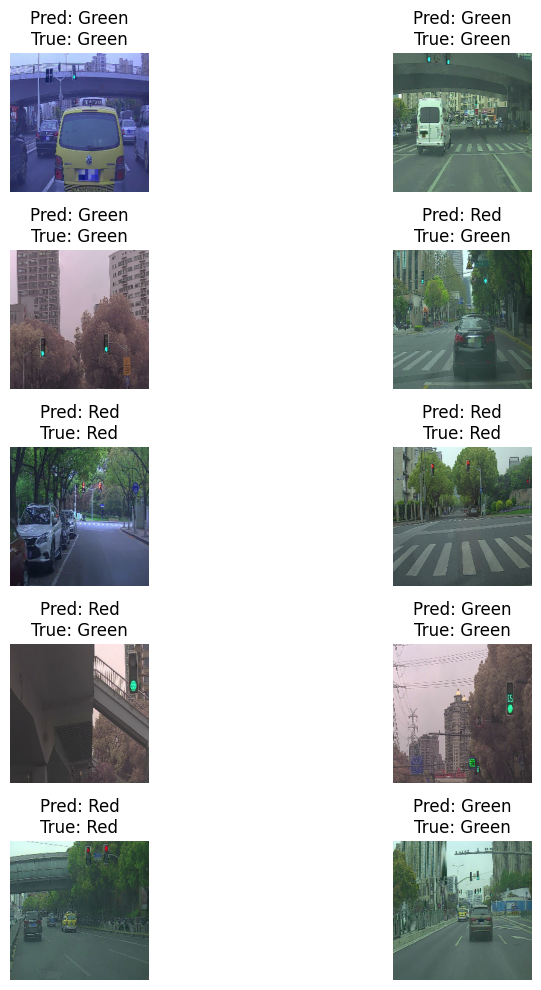

In [118]:
import matplotlib.pyplot as plt

num_predictions_to_show = 10 # Display predictions for the first 10 images in the test set

plt.figure(figsize=(10, 10))

for i, (image_batch, label_batch) in enumerate(test_ds.take(1)):
    predictions = model.predict(image_batch)

    for j in range(num_predictions_to_show):
        predicted_label = "Red" if predictions[j] > 0.5 else "Green"
        true_label = class_names[label_batch[j].numpy()]

        plt.subplot(5, 2, j + 1)
        plt.imshow(image_batch[j].numpy())
        plt.title(f"Pred: {predicted_label}\nTrue: {true_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [108]:
traffic = tf.keras.preprocessing.image_dataset_from_directory(
    'traffic_data/traffic',
    image_size=img_size,
    batch_size=batch_size
)

class_names = traffic.class_names
print("Classes:", class_names)

Found 200 files belonging to 2 classes.
Classes: ['Green', 'Red']


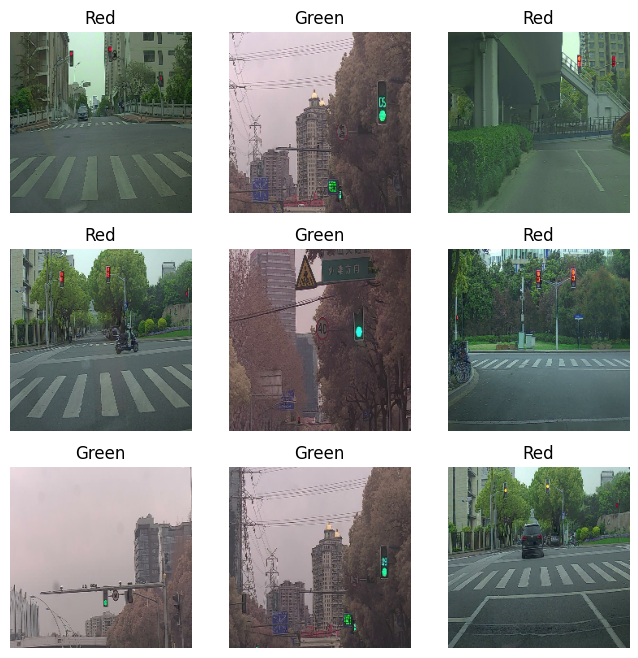

In [109]:
plt.figure(figsize=(8, 8))

for images, labels in traffic.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [110]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [111]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [112]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.5625 - loss: 1.1768 - val_accuracy: 0.5000 - val_loss: 0.6893
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - accuracy: 0.5875 - loss: 0.6887 - val_accuracy: 0.5500 - val_loss: 0.6839
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 37s 7s/step - accuracy: 0.7000 - loss: 0.6693 - val_accuracy: 0.8250 - val_loss: 0.6654
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step - accuracy: 0.5063 - loss: 0.6996 - val_accuracy: 0.4750 - val_loss: 0.6592
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 42s 7s/step - accuracy: 0.6938 - loss: 0.6210 - val_accuracy: 0.6250 - val_loss: 0.6769
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.7250 - loss: 0.6007 - val_accuracy: 0.7000 - val_loss: 0.6196
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.7125 - loss: 0.5819 - val_accuracy: 0.6750 - val_loss: 0.6259
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.7188 - loss: 0.5364 - val_accuracy: 0.7500 - val_loss: 0.5886
Epoch 9/

In [113]:
model.evaluate(val_data)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 581ms/step - accuracy: 0.7500 - loss: 0.5670


[0.5669703483581543, 0.75]

In [119]:
print("Evaluating model on the test dataset:")
model.evaluate(test_ds)

Evaluating model on the test dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9000 - loss: 0.4291


[0.4290936589241028, 0.8999999761581421]

In [120]:
print("\nMaking predictions on a batch from the test dataset:")
for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    for i in range(len(labels)):
        predicted_class_idx = (predictions[i] > 0.5).astype(int)[0]
        predicted_label = class_names[predicted_class_idx]
        true_label = class_names[labels[i].numpy()]
        print(f"Image {i+1}: Predicted: {predicted_label}, True: {true_label}")


Making predictions on a batch from the test dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Image 1: Predicted: Green, True: Green
Image 2: Predicted: Green, True: Green
Image 3: Predicted: Green, True: Green
Image 4: Predicted: Red, True: Green
Image 5: Predicted: Red, True: Red
Image 6: Predicted: Red, True: Red
Image 7: Predicted: Red, True: Green
Image 8: Predicted: Green, True: Green
Image 9: Predicted: Red, True: Red
Image 10: Predicted: Green, True: Green
Image 11: Predicted: Green, True: Green
Image 12: Predicted: Red, True: Red
Image 13: Predicted: Red, True: Red
Image 14: Predicted: Green, True: Green
Image 15: Predicted: Red, True: Red
Image 16: Predicted: Green, True: Green
Image 17: Predicted: Green, True: Red
Image 18: Predicted: Green, True: Green
Image 19: Predicted: Green, True: Green
Image 20: Predicted: Red, True: Red
Image 21: Predicted: Red, True: Red
Image 22: Predicted: Green, True: Green
Image 23: Predicted: Red, True: Red
Image 24: Predicted: Red, True: Red
Image

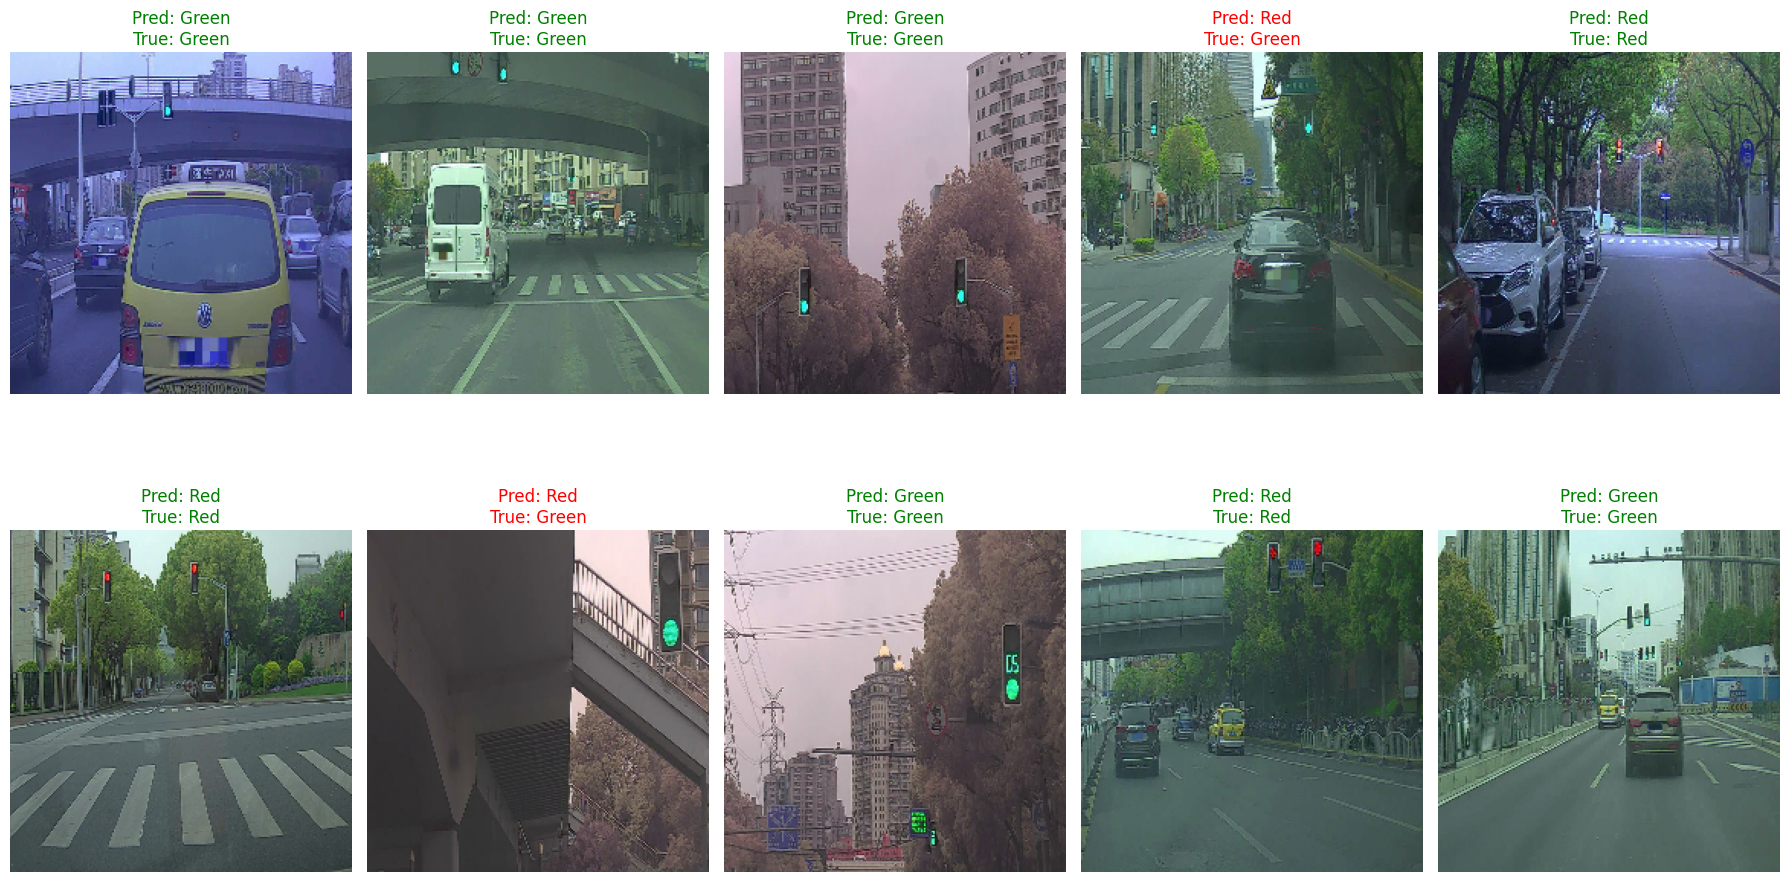

In [132]:
num_images_to_display = 10 # You can change this number

plt.figure(figsize=(18, 48))

# Take one batch from the test_ds
for images, labels in test_ds.take(1):
    predictions = model.predict(images, verbose=0)

    for i in range(num_images_to_display):
        plt.subplot(num_images_to_display, 5, i + 1) # Adjust subplot grid dynamically
        plt.imshow(images[i].numpy())

        predicted_class_idx = (predictions[i] > 0.5).astype(int)[0]
        predicted_label = class_names[predicted_class_idx]
        true_label = class_names[labels[i].numpy()]

        color = "green" if predicted_label == true_label else "red"
        plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
        plt.axis("off")

plt.tight_layout()
plt.show()